# Google Play 10k+ Review EDA and Data Quality Check

This run is the next step after the earlier Google Play / iOS validation runs.

Before moving into SQL or database design, I want to look more closely at the actual Google Play review data itself. The main goal is to check whether the data is clean and useful enough for later analysis, modeling, and recurring ingestion.

For this run, I collected 10 mainstream Google Play apps and targeted 1,200 reviews per app, for a total target of 12,000 reviews.

In [63]:
!pip install google-play-scraper langdetect textblob scikit-learn -q

## 1. Setup

I am setting up the packages, run ID, and output folder first.  
The run ID is important because later I can compare this run with future runs without mixing files.

In [64]:
import pandas as pd
import numpy as np
import re
import time
import json
import zipfile
import hashlib
from pathlib import Path
from datetime import datetime, timezone

from google_play_scraper import Sort, reviews
from google_play_scraper import app as gp_app

from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 0

from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

from IPython.display import display, Markdown

import matplotlib.pyplot as plt

In [65]:
RUN_TS = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
RUN_ID = f"googleplay_10k_eda_{RUN_TS}"

OUTPUT_DIR = Path("/content/googleplay_10k_eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Run ID:", RUN_ID)
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIG_DIR)

Run ID: googleplay_10k_eda_20260626_205621
Output directory: /content/googleplay_10k_eda_outputs
Figure directory: /content/googleplay_10k_eda_outputs/figures


## 2. App List

I used 10 mainstream apps across different categories.  
The sample is not meant to represent the whole Google Play Store, but it is large enough to check data quality across different app types.

In [66]:
APPS = {
    "YouTube": "com.google.android.youtube",
    "TikTok": "com.zhiliaoapp.musically",
    "Instagram": "com.instagram.android",
    "Spotify": "com.spotify.music",
    "Uber": "com.ubercab",
    "DoorDash": "com.dd.doordash",
    "Duolingo": "com.duolingo",
    "Netflix": "com.netflix.mediaclient",
    "Airbnb": "com.airbnb.android",
    "Walmart": "com.walmart.android"
}

LANG = "en"
COUNTRY = "us"
TARGET_PER_APP = 1200
PAGE_SIZE = 200

print("Number of apps:", len(APPS))
print("Target reviews per app:", TARGET_PER_APP)
print("Target total reviews:", len(APPS) * TARGET_PER_APP)

Number of apps: 10
Target reviews per app: 1200
Target total reviews: 12000


## 3. App Metadata Check

Before collecting reviews, I first checked whether each app ID is valid and saved basic app metadata.

In [68]:
metadata_rows = []

for app_name, app_id in APPS.items():
    try:
        info = gp_app(app_id, lang=LANG, country=COUNTRY)
        metadata_rows.append({
            "app_name_input": app_name,
            "app_id": app_id,
            "title": info.get("title"),
            "score": info.get("score"),
            "ratings": info.get("ratings"),
            "reviews": info.get("reviews"),
            "installs": info.get("installs"),
            "genre": info.get("genre"),
            "developer": info.get("developer"),
            "updated": info.get("updated"),
            "version": info.get("version"),
            "url": info.get("url")
        })
        print(f"OK: {app_name} -> {info.get('title')}")
    except Exception as e:
        print(f"FAILED: {app_name} / {app_id}: {e}")

metadata_df = pd.DataFrame(metadata_rows)
metadata_df

OK: YouTube -> YouTube
OK: TikTok -> TikTok - Videos, Shop & LIVE
OK: Instagram -> Instagram
OK: Spotify -> Spotify: Music and Podcasts
OK: Uber -> Uber - Request a ride
OK: DoorDash -> DoorDash: Food, Grocery, More
OK: Duolingo -> Duolingo: Language Lessons
OK: Netflix -> Netflix
OK: Airbnb -> Airbnb
OK: Walmart -> Walmart: Shopping & Savings


,app_name_input,app_id,title,score,ratings,reviews,installs,genre,developer,updated,version,url
0,YouTube,com.google.android.youtube,YouTube,3.864873,170807378,2979570,"10,000,000,000+",Video Players & Editors,Google LLC,1782504177,Varies with device,https://play.google.com/store/apps/details?id=...
1,TikTok,com.zhiliaoapp.musically,"TikTok - Videos, Shop & LIVE",3.994372,69199900,2252674,"1,000,000,000+",Social,TikTok Pte. Ltd.,1782469843,Varies with device,https://play.google.com/store/apps/details?id=...
2,Instagram,com.instagram.android,Instagram,4.004118,168247942,4560885,"5,000,000,000+",Social,Instagram,1782191758,Varies with device,https://play.google.com/store/apps/details?id=...
3,Spotify,com.spotify.music,Spotify: Music and Podcasts,4.333650,35822990,1841373,"1,000,000,000+",Music & Audio,Spotify AB,1782397000,Varies with device,https://play.google.com/store/apps/details?id=...
4,Uber,com.ubercab,Uber - Request a ride,4.744739,18963267,429663,"1,000,000,000+",Maps & Navigation,"Uber Technologies, Inc.",1781945871,Varies with device,https://play.google.com/store/apps/details?id=...
5,DoorDash,com.dd.doordash,"DoorDash: Food, Grocery, More",4.656841,5997546,699487,"50,000,000+",Food & Drink,DoorDash,1782247583,15.280.2,https://play.google.com/store/apps/details?id=...
6,Duolingo,com.duolingo,Duolingo: Language Lessons,4.725954,46819455,947842,"500,000,000+",Education,Duolingo,1782244290,Varies with device,https://play.google.com/store/apps/details?id=...
7,Netflix,com.netflix.mediaclient,Netflix,3.873158,15158236,910101,"1,000,000,000+",Entertainment,"Netflix, Inc.",1782172725,Varies with device,https://play.google.com/store/apps/details?id=...
8,Airbnb,com.airbnb.android,Airbnb,4.551163,1923314,101305,"100,000,000+",Travel & Local,Airbnb,1782255607,26.25.1,https://play.google.com/store/apps/details?id=...
9,Walmart,com.walmart.android,Walmart: Shopping & Savings,4.717994,7156910,563140,"100,000,000+",Shopping,Walmart,1782489166,26.23.1,https://play.google.com/store/apps/details?id=...


In [69]:
metadata_path = OUTPUT_DIR / f"{RUN_ID}_app_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

print("Saved:", metadata_path)

Saved: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_app_metadata.csv


## 4. Collect Google Play Reviews

I collect reviews in batches instead of trying to pull everything at once.  
This makes the process easier to monitor and also gives me a cleaner record of the collection process.

In [70]:
def fetch_reviews_for_app(app_name, app_id, target_count=1200, page_size=200, sleep_seconds=1):
    all_rows = []
    continuation_token = None
    page = 0

    while len(all_rows) < target_count:
        try:
            if continuation_token is None:
                batch, continuation_token = reviews(
                    app_id,
                    lang=LANG,
                    country=COUNTRY,
                    sort=Sort.NEWEST,
                    count=page_size
                )
            else:
                batch, continuation_token = reviews(
                    app_id,
                    continuation_token=continuation_token
                )

            page += 1

            if not batch:
                print(f"{app_name}: no more reviews returned.")
                break

            needed = target_count - len(all_rows)
            batch = batch[:needed]

            for r in batch:
                r["app_name"] = app_name
                r["app_id"] = app_id
                r["collection_run_id"] = RUN_ID
                r["collection_timestamp_utc"] = datetime.now(timezone.utc).isoformat()
                r["source_lang"] = LANG
                r["source_country"] = COUNTRY

            all_rows.extend(batch)
            print(f"{app_name}: page {page}, collected {len(all_rows)} / {target_count}")

            if continuation_token is None:
                print(f"{app_name}: continuation token ended.")
                break

            time.sleep(sleep_seconds)

        except Exception as e:
            print(f"{app_name}: error on page {page + 1}: {e}")
            break

    return pd.DataFrame(all_rows)

In [71]:
all_review_dfs = []
collection_log = []

for app_name, app_id in APPS.items():
    print("\n" + "="*80)
    print("Collecting:", app_name)
    print("="*80)

    app_reviews = fetch_reviews_for_app(
        app_name=app_name,
        app_id=app_id,
        target_count=TARGET_PER_APP,
        page_size=PAGE_SIZE,
        sleep_seconds=1
    )

    all_review_dfs.append(app_reviews)

    collection_log.append({
        "app_name": app_name,
        "app_id": app_id,
        "rows_collected": len(app_reviews),
        "target_count": TARGET_PER_APP,
        "collection_status": "complete" if len(app_reviews) == TARGET_PER_APP else "partial"
    })

    temp_df = pd.concat([x for x in all_review_dfs if len(x) > 0], ignore_index=True)
    temp_path = OUTPUT_DIR / f"{RUN_ID}_raw_reviews_incremental.csv"
    temp_df.to_csv(temp_path, index=False)

    print(f"Saved incremental file with {len(temp_df)} rows.")

raw_df = pd.concat([x for x in all_review_dfs if len(x) > 0], ignore_index=True)

collection_log_df = pd.DataFrame(collection_log)

print("Final raw shape:", raw_df.shape)
display(collection_log_df)
raw_df.head()


Collecting: YouTube
YouTube: page 1, collected 200 / 1200
YouTube: page 2, collected 400 / 1200
YouTube: page 3, collected 600 / 1200
YouTube: page 4, collected 800 / 1200
YouTube: page 5, collected 1000 / 1200
YouTube: page 6, collected 1200 / 1200
Saved incremental file with 1200 rows.

Collecting: TikTok
TikTok: page 1, collected 200 / 1200
TikTok: page 2, collected 400 / 1200
TikTok: page 3, collected 600 / 1200
TikTok: page 4, collected 800 / 1200
TikTok: page 5, collected 1000 / 1200
TikTok: page 6, collected 1200 / 1200


/tmp/ipykernel_4840/294500612.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp_df = pd.concat([x for x in all_review_dfs if len(x) > 0], ignore_index=True)


Saved incremental file with 2400 rows.

Collecting: Instagram
Instagram: page 1, collected 200 / 1200
Instagram: page 2, collected 400 / 1200
Instagram: page 3, collected 600 / 1200
Instagram: page 4, collected 800 / 1200
Instagram: page 5, collected 1000 / 1200
Instagram: page 6, collected 1200 / 1200
Saved incremental file with 3600 rows.

Collecting: Spotify
Spotify: page 1, collected 200 / 1200
Spotify: page 2, collected 400 / 1200
Spotify: page 3, collected 600 / 1200
Spotify: page 4, collected 800 / 1200
Spotify: page 5, collected 1000 / 1200
Spotify: page 6, collected 1200 / 1200


/tmp/ipykernel_4840/294500612.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp_df = pd.concat([x for x in all_review_dfs if len(x) > 0], ignore_index=True)


Saved incremental file with 4800 rows.

Collecting: Uber
Uber: page 1, collected 200 / 1200
Uber: page 2, collected 400 / 1200
Uber: page 3, collected 600 / 1200
Uber: page 4, collected 800 / 1200
Uber: page 5, collected 1000 / 1200
Uber: page 6, collected 1200 / 1200


...

/tmp/ipykernel_4840/294500612.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp_df = pd.concat([x for x in all_review_dfs if len(x) > 0], ignore_index=True)


Saved incremental file with 12000 rows.
Final raw shape: (12000, 17)


/tmp/ipykernel_4840/294500612.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  raw_df = pd.concat([x for x in all_review_dfs if len(x) > 0], ignore_index=True)


,app_name,app_id,rows_collected,target_count,collection_status
0,YouTube,com.google.android.youtube,1200,1200,complete
1,TikTok,com.zhiliaoapp.musically,1200,1200,complete
2,Instagram,com.instagram.android,1200,1200,complete
3,Spotify,com.spotify.music,1200,1200,complete
4,Uber,com.ubercab,1200,1200,complete
5,DoorDash,com.dd.doordash,1200,1200,complete
6,Duolingo,com.duolingo,1200,1200,complete
7,Netflix,com.netflix.mediaclient,1200,1200,complete
8,Airbnb,com.airbnb.android,1200,1200,complete
9,Walmart,com.walmart.android,1200,1200,complete


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id,collection_run_id,collection_timestamp_utc,source_lang,source_country
0,ea771641-6a35-4a7f-9a41-35331c9b4dc2,Kenneth Gosalamang,https://play-lh.googleusercontent.com/a/ACg8oc...,not opening,1,0,10.37.58,2026-06-25 20:57:06,None,NaT,10.37.58,YouTube,com.google.android.youtube,googleplay_10k_eda_20260626_205621,2026-06-26T20:57:52.716129+00:00,en,us
1,106ed506-f388-4283-b749-61e670b96760,Dylan Martinez,https://play-lh.googleusercontent.com/a-/ALV-U...,I like it,5,0,21.25.523,2026-06-25 20:54:19,None,NaT,21.25.523,YouTube,com.google.android.youtube,googleplay_10k_eda_20260626_205621,2026-06-26T20:57:52.716172+00:00,en,us
2,2bb94906-2de8-4c22-8abf-1e15fef70038,Jazzie Pittman,https://play-lh.googleusercontent.com/a/ACg8oc...,it's good for enough me 😁☺️,5,0,21.07.246,2026-06-25 20:52:44,None,NaT,21.07.246,YouTube,com.google.android.youtube,googleplay_10k_eda_20260626_205621,2026-06-26T20:57:52.716180+00:00,en,us
3,77a4741c-aa27-4657-b853-da92fb127e89,Agung tri wibawa,https://play-lh.googleusercontent.com/a/ACg8oc...,oke,5,0,21.25.523,2026-06-25 20:52:30,None,NaT,21.25.523,YouTube,com.google.android.youtube,googleplay_10k_eda_20260626_205621,2026-06-26T20:57:52.716186+00:00,en,us
4,816affae-ce29-44a3-8074-7e3606e2ef13,Alexa Pipo (Lima),https://play-lh.googleusercontent.com/a-/ALV-U...,good good global youtuve,5,1,20.38.37,2026-06-25 20:51:34,None,NaT,20.38.37,YouTube,com.google.android.youtube,googleplay_10k_eda_20260626_205621,2026-06-26T20:57:52.716191+00:00,en,us


In [72]:
raw_path = OUTPUT_DIR / f"{RUN_ID}_raw_reviews_internal.csv"
collection_log_path = OUTPUT_DIR / f"{RUN_ID}_collection_log.csv"

raw_df.to_csv(raw_path, index=False)
collection_log_df.to_csv(collection_log_path, index=False)

print("Saved raw internal file:", raw_path)
print("Saved collection log:", collection_log_path)

Saved raw internal file: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_raw_reviews_internal.csv
Saved collection log: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_collection_log.csv


## 5. Basic Schema Check

This section checks the number of rows, apps, columns, and data types.  
This helps confirm that the collection finished correctly before moving into EDA.

In [73]:
print("Rows:", len(raw_df))
print("Columns:", raw_df.shape[1])
print("Apps:", raw_df["app_name"].nunique())
print("App list:", sorted(raw_df["app_name"].unique()))

raw_df.info()

Rows: 12000
Columns: 17
Apps: 10
App list: ['Airbnb', 'DoorDash', 'Duolingo', 'Instagram', 'Netflix', 'Spotify', 'TikTok', 'Uber', 'Walmart', 'YouTube']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   reviewId                  12000 non-null  object        
 1   userName                  12000 non-null  object        
 2   userImage                 12000 non-null  object        
 3   content                   12000 non-null  object        
 4   score                     12000 non-null  int64         
 5   thumbsUpCount             12000 non-null  int64         
 6   reviewCreatedVersion      9881 non-null   object        
 7   at                        12000 non-null  datetime64[ns]
 8   replyContent              2219 non-null   object        
 9   repliedAt                 2219 non-null   datetime6

In [74]:
raw_df.head(3).T

,0,1,2
reviewId,ea771641-6a35-4a7f-9a41-35331c9b4dc2,106ed506-f388-4283-b749-61e670b96760,2bb94906-2de8-4c22-8abf-1e15fef70038
userName,Kenneth Gosalamang,Dylan Martinez,Jazzie Pittman
userImage,https://play-lh.googleusercontent.com/a/ACg8oc...,https://play-lh.googleusercontent.com/a-/ALV-U...,https://play-lh.googleusercontent.com/a/ACg8oc...
content,not opening,I like it,it's good for enough me 😁☺️
score,1,5,5
thumbsUpCount,0,0,0
reviewCreatedVersion,10.37.58,21.25.523,21.07.246
at,2026-06-25 20:57:06,2026-06-25 20:54:19,2026-06-25 20:52:44
replyContent,None,None,None
repliedAt,NaT,NaT,NaT


## 6. Clean Basic Fields and Create Review Features

I keep the raw data as-is, then create a working dataframe for EDA.  
The main added fields are normalized text, review length, word count, and review date.

In [75]:
df = raw_df.copy()

# Convert timestamps
df["at"] = pd.to_datetime(df["at"], errors="coerce")
df["repliedAt"] = pd.to_datetime(df["repliedAt"], errors="coerce")

# Make sure content is text
df["content"] = df["content"].fillna("").astype(str)

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    return text.strip()

df["content_norm"] = df["content"].apply(normalize_text)

# Text length features
df["char_len"] = df["content"].str.len()
df["word_count"] = df["content"].apply(lambda x: len(re.findall(r"\b\w+\b", str(x))))
df["review_date"] = df["at"].dt.date

df[["app_name", "score", "content", "char_len", "word_count", "at", "appVersion"]].head()

,app_name,score,content,char_len,word_count,at,appVersion
0,YouTube,1,not opening,11,2,2026-06-25 20:57:06,10.37.58
1,YouTube,5,I like it,9,3,2026-06-25 20:54:19,21.25.523
2,YouTube,5,it's good for enough me 😁☺️,27,6,2026-06-25 20:52:44,21.07.246
3,YouTube,5,oke,3,1,2026-06-25 20:52:30,21.25.523
4,YouTube,5,good good global youtuve,24,4,2026-06-25 20:51:34,20.38.37


## 7. Overall Summary

This gives a quick view of the full dataset size, time range, ratings, and text length.

In [76]:
overall_summary = pd.DataFrame([{
    "total_reviews": len(df),
    "unique_apps": df["app_name"].nunique(),
    "unique_review_ids": df["reviewId"].nunique() if "reviewId" in df.columns else np.nan,
    "earliest_review_time": df["at"].min(),
    "latest_review_time": df["at"].max(),
    "avg_rating": df["score"].mean(),
    "median_rating": df["score"].median(),
    "avg_char_len": df["char_len"].mean(),
    "median_char_len": df["char_len"].median(),
    "avg_word_count": df["word_count"].mean(),
    "median_word_count": df["word_count"].median()
}])

overall_summary

,total_reviews,unique_apps,unique_review_ids,earliest_review_time,latest_review_time,avg_rating,median_rating,avg_char_len,median_char_len,avg_word_count,median_word_count
0,12000,10,12000,2026-05-28 17:50:21,2026-06-25 20:57:50,3.744417,5.0,74.871833,28.0,14.25575,5.0


In [77]:
overall_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_overall_summary.csv", index=False)

## 8. App-Level Summary

I compare the apps separately because the data quality is not the same across apps.  
This table checks ratings, review length, timestamp range, version coverage, and developer reply coverage by app.

In [78]:
app_summary = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    unique_review_ids=("reviewId", "nunique"),
    avg_rating=("score", "mean"),
    median_rating=("score", "median"),
    pct_1_star=("score", lambda s: (s == 1).mean() * 100),
    pct_5_star=("score", lambda s: (s == 5).mean() * 100),
    avg_char_len=("char_len", "mean"),
    median_char_len=("char_len", "median"),
    avg_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    earliest_review=("at", "min"),
    latest_review=("at", "max"),
    app_version_coverage=("appVersion", lambda s: s.notna().mean() * 100),
    review_created_version_coverage=("reviewCreatedVersion", lambda s: s.notna().mean() * 100),
    developer_reply_coverage=("replyContent", lambda s: s.notna().mean() * 100)
).reset_index()

app_summary = app_summary.sort_values("app_name").reset_index(drop=True)
app_summary

,app_name,n_reviews,unique_review_ids,avg_rating,median_rating,pct_1_star,pct_5_star,avg_char_len,median_char_len,avg_word_count,median_word_count,earliest_review,latest_review,app_version_coverage,review_created_version_coverage,developer_reply_coverage
0,Airbnb,1200,1200,4.080000,5.0,18.666667,71.250000,78.445000,32.0,14.510000,6.0,2026-05-28 17:50:21,2026-06-25 20:42:31,87.583333,87.583333,0.166667
1,DoorDash,1200,1200,3.053333,3.0,38.500000,41.666667,111.117500,60.0,21.244167,11.0,2026-06-16 14:19:39,2026-06-25 20:15:53,89.416667,89.416667,0.000000
2,Duolingo,1200,1200,4.456667,5.0,6.833333,75.583333,58.878333,27.0,11.435833,5.0,2026-06-25 04:39:13,2026-06-25 20:56:02,89.500000,89.500000,0.000000
3,Instagram,1200,1200,3.745833,5.0,25.333333,60.916667,60.817500,19.0,11.120833,4.0,2026-06-25 11:21:20,2026-06-25 20:57:33,62.750000,62.750000,0.000000
4,Netflix,1200,1200,3.219167,4.0,36.750000,47.250000,89.635833,39.5,16.753333,8.0,2026-06-15 06:42:46,2026-06-25 20:33:30,69.333333,69.333333,0.000000
5,Spotify,1200,1200,3.665000,5.0,24.166667,55.083333,81.485833,33.0,15.867500,6.0,2026-06-24 09:25:51,2026-06-25 20:15:10,84.916667,84.916667,11.416667
6,TikTok,1200,1200,3.912500,5.0,20.500000,65.000000,54.311667,16.0,10.686667,3.0,2026-06-24 11:07:06,2026-06-25 20:57:50,62.000000,62.000000,84.500000
7,Uber,1200,1200,3.737500,5.0,26.333333,62.416667,75.708333,20.0,14.320833,4.0,2026-06-23 04:52:34,2026-06-25 20:50:22,85.333333,85.333333,0.250000
8,Walmart,1200,1200,3.791667,5.0,18.083333,57.083333,95.486667,44.0,18.258333,8.0,2026-06-19 00:03:20,2026-06-25 20:52:49,94.750000,94.750000,88.583333
9,YouTube,1200,1200,3.782500,5.0,23.083333,61.833333,42.831667,12.0,8.360000,2.0,2026-06-25 08:41:24,2026-06-25 20:57:06,97.833333,97.833333,0.000000


In [79]:
app_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_app_level_summary.csv", index=False)

## 9. Rating Distribution

Here I check how ratings are distributed overall and by app.  
This matters because a dataset with only one type of rating would be less useful for later modeling.

In [80]:
rating_counts = pd.crosstab(df["app_name"], df["score"])
rating_pct = pd.crosstab(df["app_name"], df["score"], normalize="index") * 100

display(rating_counts)
display(rating_pct.round(2))

score,1,2,3,4,5
app_name,,,,,
Airbnb,224,30,27,64,855
DoorDash,462,83,84,71,500
Duolingo,82,30,53,128,907
Instagram,304,41,42,82,731
Netflix,441,64,53,75,567
Spotify,290,62,69,118,661
TikTok,246,46,55,73,780
Uber,316,41,34,60,749
Walmart,217,95,94,109,685


score,1,2,3,4,5
app_name,,,,,
Airbnb,18.67,2.50,2.25,5.33,71.25
DoorDash,38.50,6.92,7.00,5.92,41.67
Duolingo,6.83,2.50,4.42,10.67,75.58
Instagram,25.33,3.42,3.50,6.83,60.92
Netflix,36.75,5.33,4.42,6.25,47.25
Spotify,24.17,5.17,5.75,9.83,55.08
TikTok,20.50,3.83,4.58,6.08,65.00
Uber,26.33,3.42,2.83,5.00,62.42
Walmart,18.08,7.92,7.83,9.08,57.08


In [81]:
overall_rating_counts = df["score"].value_counts().sort_index()
overall_rating_pct = (overall_rating_counts / len(df) * 100).round(2)

overall_rating_summary = pd.DataFrame({
    "rating": overall_rating_counts.index,
    "count": overall_rating_counts.values,
    "pct": overall_rating_pct.values
})

overall_rating_summary

,rating,count,pct
0,1,2859,23.82
1,2,547,4.56
2,3,573,4.78
3,4,844,7.03
4,5,7177,59.81


In [82]:
rating_counts.to_csv(OUTPUT_DIR / f"{RUN_ID}_rating_counts_by_app.csv")
rating_pct.round(2).to_csv(OUTPUT_DIR / f"{RUN_ID}_rating_pct_by_app.csv")
overall_rating_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_overall_rating_summary.csv", index=False)

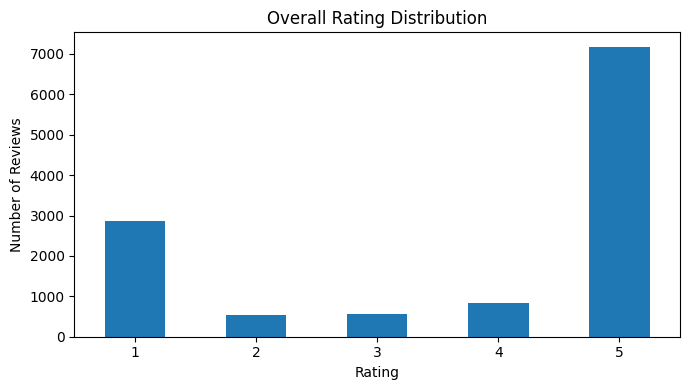

Saved figure: /content/googleplay_10k_eda_outputs/figures/googleplay_10k_eda_20260626_205621_overall_rating_distribution.png


In [83]:
plt.figure(figsize=(7, 4))
overall_rating_counts.plot(kind="bar")
plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()

rating_fig_path = FIG_DIR / f"{RUN_ID}_overall_rating_distribution.png"
plt.savefig(rating_fig_path, dpi=150)
plt.show()

print("Saved figure:", rating_fig_path)

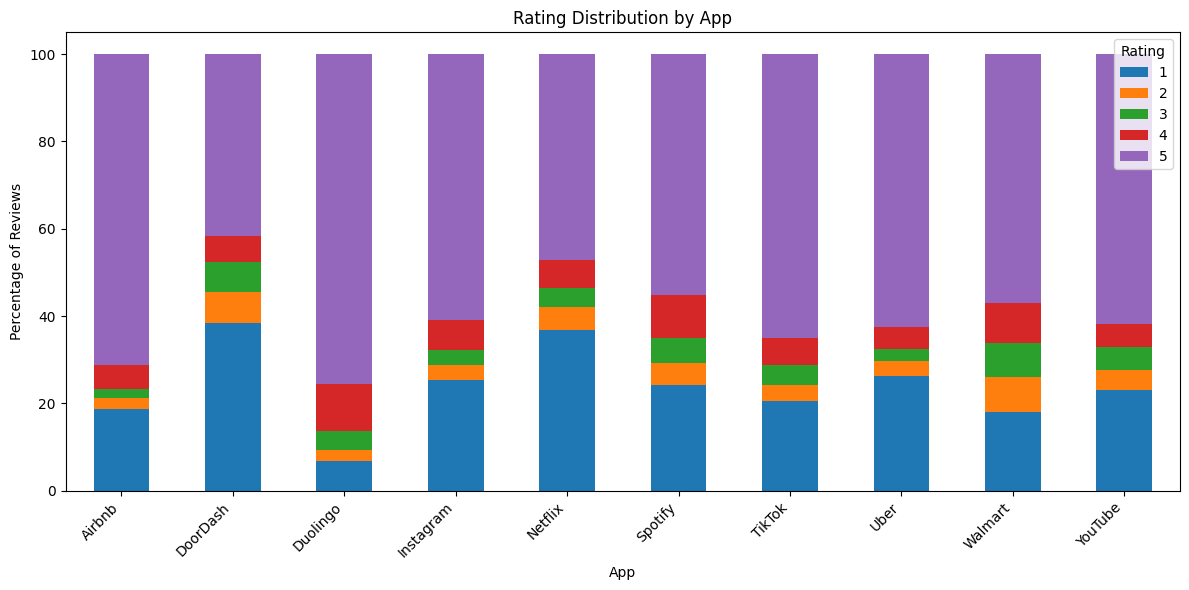

Saved figure: /content/googleplay_10k_eda_outputs/figures/googleplay_10k_eda_20260626_205621_rating_distribution_by_app.png


In [84]:
rating_pct.sort_index().plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Rating Distribution by App")
plt.xlabel("App")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Rating")
plt.tight_layout()

rating_app_fig_path = FIG_DIR / f"{RUN_ID}_rating_distribution_by_app.png"
plt.savefig(rating_app_fig_path, dpi=150)
plt.show()

print("Saved figure:", rating_app_fig_path)

## 10. Review Length

This section checks whether the reviews have enough text for later analysis.  
Very short reviews are still useful for rating analysis, but they may not be useful for text modeling.

In [85]:
length_summary = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    avg_char_len=("char_len", "mean"),
    p25_char_len=("char_len", lambda s: s.quantile(0.25)),
    median_char_len=("char_len", "median"),
    p75_char_len=("char_len", lambda s: s.quantile(0.75)),
    p95_char_len=("char_len", lambda s: s.quantile(0.95)),
    avg_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    pct_very_short_3_words_or_less=("word_count", lambda s: (s <= 3).mean() * 100)
).reset_index()

length_summary

,app_name,n_reviews,avg_char_len,p25_char_len,median_char_len,p75_char_len,p95_char_len,avg_word_count,median_word_count,pct_very_short_3_words_or_less
0,Airbnb,1200,78.445000,13.0,32.0,85.0,372.40,14.510000,6.0,34.916667
1,DoorDash,1200,111.117500,23.0,60.0,147.0,443.05,21.244167,11.0,19.833333
2,Duolingo,1200,58.878333,11.0,27.0,64.0,236.15,11.435833,5.0,37.083333
3,Instagram,1200,60.817500,8.0,19.0,59.0,317.00,11.120833,4.0,49.166667
4,Netflix,1200,89.635833,13.0,39.5,119.0,385.15,16.753333,8.0,31.750000
5,Spotify,1200,81.485833,12.0,33.0,97.0,346.15,15.867500,6.0,34.333333
6,TikTok,1200,54.311667,8.0,16.0,47.0,253.20,10.686667,3.0,53.083333
7,Uber,1200,75.708333,8.0,20.0,83.0,398.00,14.320833,4.0,48.916667
8,Walmart,1200,95.486667,19.0,44.0,114.0,418.05,18.258333,8.0,24.916667
9,YouTube,1200,42.831667,6.0,12.0,32.0,221.05,8.360000,2.0,61.000000


In [86]:
length_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_review_length_summary.csv", index=False)

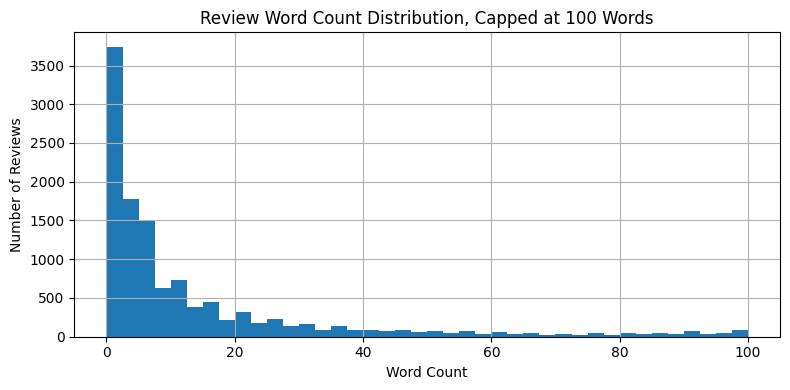

Saved figure: /content/googleplay_10k_eda_outputs/figures/googleplay_10k_eda_20260626_205621_word_count_distribution.png


In [87]:
plt.figure(figsize=(8, 4))
df["word_count"].clip(upper=100).hist(bins=40)
plt.title("Review Word Count Distribution, Capped at 100 Words")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.tight_layout()

length_fig_path = FIG_DIR / f"{RUN_ID}_word_count_distribution.png"
plt.savefig(length_fig_path, dpi=150)
plt.show()

print("Saved figure:", length_fig_path)

## 11. Missing Fields

This checks which fields are complete and which fields are incomplete.  
I separate core review fields from optional fields like developer replies.

In [88]:
key_fields = [
    "reviewId",
    "userName",
    "content",
    "score",
    "thumbsUpCount",
    "reviewCreatedVersion",
    "at",
    "replyContent",
    "repliedAt",
    "appVersion"
]

available_key_fields = [c for c in key_fields if c in df.columns]

missing_overall = (
    df[available_key_fields]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

missing_overall.columns = ["field", "missing_pct"]
missing_overall

,field,missing_pct
0,replyContent,81.51
1,repliedAt,81.51
2,reviewCreatedVersion,17.66
3,appVersion,17.66
4,userName,0.00
5,reviewId,0.00
6,thumbsUpCount,0.00
7,score,0.00
8,content,0.00
9,at,0.00


In [89]:
missing_by_app = (
    df.groupby("app_name")[available_key_fields]
    .apply(lambda x: x.isna().mean() * 100)
    .round(2)
)

missing_by_app

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
app_name,,,,,,,,,,
Airbnb,0.0,0.0,0.0,0.0,0.0,12.42,0.0,99.83,99.83,12.42
DoorDash,0.0,0.0,0.0,0.0,0.0,10.58,0.0,100.00,100.00,10.58
Duolingo,0.0,0.0,0.0,0.0,0.0,10.50,0.0,100.00,100.00,10.50
Instagram,0.0,0.0,0.0,0.0,0.0,37.25,0.0,100.00,100.00,37.25
Netflix,0.0,0.0,0.0,0.0,0.0,30.67,0.0,100.00,100.00,30.67
Spotify,0.0,0.0,0.0,0.0,0.0,15.08,0.0,88.58,88.58,15.08
TikTok,0.0,0.0,0.0,0.0,0.0,38.00,0.0,15.50,15.50,38.00
Uber,0.0,0.0,0.0,0.0,0.0,14.67,0.0,99.75,99.75,14.67
Walmart,0.0,0.0,0.0,0.0,0.0,5.25,0.0,11.42,11.42,5.25


In [90]:
missing_overall.to_csv(OUTPUT_DIR / f"{RUN_ID}_missing_overall.csv", index=False)
missing_by_app.to_csv(OUTPUT_DIR / f"{RUN_ID}_missing_by_app.csv")

## 12. Duplicate Checks

I check duplicates in two ways.

First, I check duplicate review IDs. If review IDs repeat, that could mean collection or ingestion issues.

Second, I check repeated review text. Repeated text does not always mean a collection error, because many users write the same short comments like "good" or "great app."

In [91]:
df["dup_review_id"] = df.duplicated(subset=["reviewId"], keep=False)

df["dup_content_same_app"] = df.duplicated(
    subset=["app_id", "content_norm"],
    keep=False
)

df["dup_content_global"] = df.duplicated(
    subset=["content_norm"],
    keep=False
)

duplicate_summary = pd.DataFrame([{
    "total_reviews": len(df),
    "duplicate_review_id_rows": int(df["dup_review_id"].sum()),
    "duplicate_review_id_pct": df["dup_review_id"].mean() * 100,
    "duplicate_content_same_app_rows": int(df["dup_content_same_app"].sum()),
    "duplicate_content_same_app_pct": df["dup_content_same_app"].mean() * 100,
    "duplicate_content_global_rows": int(df["dup_content_global"].sum()),
    "duplicate_content_global_pct": df["dup_content_global"].mean() * 100
}])

duplicate_summary

,total_reviews,duplicate_review_id_rows,duplicate_review_id_pct,duplicate_content_same_app_rows,duplicate_content_same_app_pct,duplicate_content_global_rows,duplicate_content_global_pct
0,12000,0,0.0,1941,16.175,2464,20.533333


In [92]:
duplicate_by_app = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    dup_review_id_pct=("dup_review_id", lambda s: s.mean() * 100),
    dup_content_same_app_pct=("dup_content_same_app", lambda s: s.mean() * 100),
    dup_content_global_pct=("dup_content_global", lambda s: s.mean() * 100)
).reset_index()

duplicate_by_app

,app_name,n_reviews,dup_review_id_pct,dup_content_same_app_pct,dup_content_global_pct
0,Airbnb,1200,0.0,18.166667,22.583333
1,DoorDash,1200,0.0,5.416667,9.333333
2,Duolingo,1200,0.0,14.750000,19.666667
3,Instagram,1200,0.0,20.583333,25.833333
4,Netflix,1200,0.0,14.166667,17.750000
5,Spotify,1200,0.0,14.416667,18.833333
6,TikTok,1200,0.0,16.083333,20.500000
7,Uber,1200,0.0,28.250000,32.583333
8,Walmart,1200,0.0,8.833333,12.500000
9,YouTube,1200,0.0,21.083333,25.750000


In [93]:
duplicate_examples = df[df["dup_content_same_app"]].sort_values(
    ["app_name", "content_norm"]
)[["app_name", "score", "content", "at", "reviewId"]].head(50)

duplicate_examples

,app_name,score,content,at,reviewId
9922,Airbnb,5,always easy to use,2026-06-18 09:04:17,e32b5e94-66e9-47c9-94ff-2f8d93e07658
10418,Airbnb,5,always easy to use,2026-06-06 18:04:15,4cf4b247-f4b9-47ce-893c-e559b0853cd6
9609,Airbnb,5,amazing,2026-06-25 15:36:57,954c0c08-425b-4aa1-b618-ddcc6c01fde7
9623,Airbnb,5,amazing,2026-06-25 10:18:45,25b747c6-da9d-4e3c-b82b-79a8f4c74d28
9917,Airbnb,5,amazing,2026-06-18 12:20:14,11cf8159-090b-495d-9047-ffe2252f761b
10101,Airbnb,4,Amazing,2026-06-14 10:28:05,067508c0-077c-441f-8d38-7f8a5eed5762
10441,Airbnb,5,Amazing,2026-06-06 12:51:29,0d07e63b-a011-4215-b500-7762c3a7f2b5
10735,Airbnb,5,amazing,2026-05-30 07:12:43,1aa637ac-7a8f-4489-9954-bfea1bc4f7cc
10798,Airbnb,5,amazing,2026-05-28 18:17:04,159b52c6-1f7a-45b3-801d-9c2a3e0ec954
9603,Airbnb,5,awesome,2026-06-25 18:37:03,340e444d-ade6-47f7-8487-3f6e9a8f7810


In [94]:
duplicate_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_duplicate_summary.csv", index=False)
duplicate_by_app.to_csv(OUTPUT_DIR / f"{RUN_ID}_duplicate_by_app.csv", index=False)
duplicate_examples.to_csv(OUTPUT_DIR / f"{RUN_ID}_duplicate_examples.csv", index=False)

## 13. Near-Duplicate Review Text

Exact duplicates are easy to check, but near-duplicates are harder.  
For this part, I use a simple TF-IDF + cosine similarity check to find review texts that are very similar but not exactly the same.

This is only a quality check, not a final spam model.

In [95]:
def find_near_duplicate_pairs(input_df, threshold=0.92, min_chars=25, max_rows_per_app=1500):
    all_pairs = []

    for app_name, group in input_df.groupby("app_name"):
        temp = group[group["content_norm"].str.len() >= min_chars].copy()

        if len(temp) < 2:
            continue

        if len(temp) > max_rows_per_app:
            temp = temp.sample(max_rows_per_app, random_state=42)

        vectorizer = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=50000
        )

        try:
            X = vectorizer.fit_transform(temp["content_norm"])

            if X.shape[0] < 2:
                continue

            n_neighbors = min(4, X.shape[0])
            nn = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
            nn.fit(X)

            distances, indices = nn.kneighbors(X)
            temp_indices = temp.index.to_list()

            for i in range(len(temp_indices)):
                for neighbor_pos in range(1, n_neighbors):
                    j = indices[i, neighbor_pos]
                    similarity = 1 - distances[i, neighbor_pos]

                    if similarity >= threshold:
                        idx_1 = temp_indices[i]
                        idx_2 = temp_indices[j]

                        if idx_1 < idx_2:
                            all_pairs.append({
                                "app_name": app_name,
                                "idx_1": idx_1,
                                "idx_2": idx_2,
                                "similarity": similarity,
                                "score_1": input_df.loc[idx_1, "score"],
                                "score_2": input_df.loc[idx_2, "score"],
                                "content_1": input_df.loc[idx_1, "content"],
                                "content_2": input_df.loc[idx_2, "content"]
                            })

        except Exception as e:
            print(f"Near-duplicate check failed for {app_name}: {e}")

    pairs_df = pd.DataFrame(all_pairs)

    if len(pairs_df) > 0:
        pairs_df = pairs_df.drop_duplicates(subset=["idx_1", "idx_2"])
        pairs_df = pairs_df.sort_values("similarity", ascending=False)

    return pairs_df

near_dup_pairs = find_near_duplicate_pairs(df, threshold=0.92)

print("Near-duplicate pairs found:", len(near_dup_pairs))
near_dup_pairs.head(20)

Near-duplicate pairs found: 16


,app_name,idx_1,idx_2,similarity,score_1,score_2,content_1,content_2
10,Instagram,3355,3360,1.000000,1,1,plz sir stop suspending accounts,plz sir stop suspending accounts
13,Spotify,4177,4243,1.000000,5,5,very good for listening to music,very good for listening to music 🎵🎶
8,Instagram,3060,3410,1.000000,5,5,good Social media platform,Good social media platform
1,Duolingo,7949,8292,1.000000,5,4,best for learning languages,best for learning languages
15,YouTube,134,277,0.985666,1,1,মাদারচোদেরা বালের অ্যাপ চালাও প্রতি সেকেন্ডে এ...,খানকির পোলারা ১ টা ভিডিও দেখতে গেলে ১৪ টা এডস ...
0,Airbnb,10318,10712,0.977806,5,5,Easy to use and convenient,Easy to use and convenient .
12,Spotify,4059,4790,0.970630,5,5,best ever app for listening music,best music listening app ever
3,Instagram,2557,2791,0.969955,1,1,I've been experiencing major technical issues ...,I've been experiencing major technical issues ...
2,Duolingo,8094,8378,0.948683,5,4,𝐼 𝑙𝑜𝑣𝑒 𝑡ℎ𝑖𝑠 𝑎𝑝𝑝 𝑠𝑜 𝑚𝑢𝑐ℎ 𝑏𝑒𝑐𝑎𝑢𝑠𝑒 𝑡ℎ𝑖𝑠 𝑎𝑝𝑝 𝑖𝑠 𝑣𝑒...,"𝑖𝑡'𝑠 𝑎𝑙𝑟𝑖𝑔ℎ𝑡, 𝑗𝑢𝑠𝑡 𝑖𝑓 𝑦𝑜𝑢 𝑘𝑛𝑜𝑤 𝑏𝑎𝑠𝑖𝑐 𝑐ℎ𝑒𝑠𝑠 𝑘𝑛𝑜..."
6,Instagram,2836,3144,0.943532,1,5,"Dear Instagram Team, my account (_karansingh.2...","""Dear Instagram Team, my account (@manav nade ..."


In [96]:
if len(near_dup_pairs) > 0:
    near_dup_summary = near_dup_pairs.groupby("app_name").agg(
        near_duplicate_pairs=("similarity", "size"),
        avg_similarity=("similarity", "mean"),
        max_similarity=("similarity", "max")
    ).reset_index()
else:
    near_dup_summary = pd.DataFrame(columns=[
        "app_name",
        "near_duplicate_pairs",
        "avg_similarity",
        "max_similarity"
    ])

near_dup_summary

,app_name,near_duplicate_pairs,avg_similarity,max_similarity
0,Airbnb,1,0.977806,0.977806
1,Duolingo,2,0.974342,1.000000
2,Instagram,8,0.956176,1.000000
3,Netflix,1,0.921695,0.921695
4,Spotify,2,0.985315,1.000000
5,TikTok,1,0.922595,0.922595
6,YouTube,1,0.985666,0.985666


In [97]:
near_dup_pairs.to_csv(OUTPUT_DIR / f"{RUN_ID}_near_duplicate_pairs.csv", index=False)
near_dup_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_near_duplicate_summary.csv", index=False)

## 14. Low-Signal Reviews

Some reviews are technically valid but do not say much, such as "good", "nice", or one-word comments.

I flag these because they may not be useful for later text analysis, even though they can still be useful for rating-level analysis.

In [98]:
GENERIC_PHRASES = {
    "good", "great", "nice", "bad", "ok", "okay",
    "love it", "loved it", "hate it",
    "good app", "great app", "nice app", "bad app",
    "very good", "excellent", "awesome", "perfect",
    "worst", "best", "cool", "super", "thanks",
    "not good", "very bad"
}

def low_signal_reason(row):
    text = str(row["content_norm"]).strip()
    wc = row["word_count"]

    if text == "":
        return "empty_content"

    if wc <= 2:
        return "very_short_2_words_or_less"

    if wc <= 3:
        return "short_3_words_or_less"

    if text in GENERIC_PHRASES:
        return "generic_phrase"

    if re.fullmatch(r"[\W_0-9]+", text):
        return "non_word_or_symbol_only"

    compact = text.replace(" ", "")
    if len(compact) >= 5 and len(set(compact)) <= 2:
        return "repetitive_characters"

    return ""

df["low_signal_reason"] = df.apply(low_signal_reason, axis=1)
df["low_signal"] = df["low_signal_reason"] != ""

low_signal_summary = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    low_signal_reviews=("low_signal", "sum"),
    low_signal_pct=("low_signal", lambda s: s.mean() * 100),
    avg_rating_low_signal=("score", lambda s: df.loc[s.index[df.loc[s.index, "low_signal"]], "score"].mean())
).reset_index()

low_signal_summary

,app_name,n_reviews,low_signal_reviews,low_signal_pct,avg_rating_low_signal
0,Airbnb,1200,419,34.916667,4.680191
1,DoorDash,1200,238,19.833333,4.239496
2,Duolingo,1200,445,37.083333,4.687640
3,Instagram,1200,590,49.166667,4.455932
4,Netflix,1200,381,31.750000,4.120735
5,Spotify,1200,412,34.333333,4.349515
6,TikTok,1200,638,53.166667,4.407524
7,Uber,1200,587,48.916667,4.689949
8,Walmart,1200,299,24.916667,4.645485
9,YouTube,1200,732,61.000000,4.262295


In [99]:
low_signal_reason_counts = (
    df[df["low_signal"]]
    .groupby(["app_name", "low_signal_reason"])
    .size()
    .reset_index(name="count")
    .sort_values(["app_name", "count"], ascending=[True, False])
)

low_signal_reason_counts

,app_name,low_signal_reason,count
1,Airbnb,very_short_2_words_or_less,323
0,Airbnb,short_3_words_or_less,96
3,DoorDash,very_short_2_words_or_less,161
2,DoorDash,short_3_words_or_less,77
5,Duolingo,very_short_2_words_or_less,349
4,Duolingo,short_3_words_or_less,96
8,Instagram,very_short_2_words_or_less,485
7,Instagram,short_3_words_or_less,104
6,Instagram,empty_content,1
10,Netflix,very_short_2_words_or_less,291


In [100]:
low_signal_examples = df[df["low_signal"]][
    ["app_name", "score", "content", "word_count", "low_signal_reason", "at"]
].head(50)

low_signal_examples

,app_name,score,content,word_count,low_signal_reason,at
0,YouTube,1,not opening,2,very_short_2_words_or_less,2026-06-25 20:57:06
1,YouTube,5,I like it,3,short_3_words_or_less,2026-06-25 20:54:19
3,YouTube,5,oke,1,very_short_2_words_or_less,2026-06-25 20:52:30
6,YouTube,5,RophiT,1,very_short_2_words_or_less,2026-06-25 20:50:26
7,YouTube,5,amjad ali,2,very_short_2_words_or_less,2026-06-25 20:50:08
8,YouTube,5,siuuuuuu,1,very_short_2_words_or_less,2026-06-25 20:49:28
11,YouTube,5,So good,2,very_short_2_words_or_less,2026-06-25 20:48:18
13,YouTube,5,SiyaMthanda Nyathi 1234,3,short_3_words_or_less,2026-06-25 20:43:49
14,YouTube,5,very slowly,2,very_short_2_words_or_less,2026-06-25 20:40:34
17,YouTube,5,Love YouTube app,3,short_3_words_or_less,2026-06-25 20:35:45


In [101]:
low_signal_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_low_signal_summary.csv", index=False)
low_signal_reason_counts.to_csv(OUTPUT_DIR / f"{RUN_ID}_low_signal_reason_counts.csv", index=False)
low_signal_examples.to_csv(OUTPUT_DIR / f"{RUN_ID}_low_signal_examples.csv", index=False)

## 15. Language Pattern Check

Even though the collection setting is US / English, I do not want to assume every review is English.

Short reviews are marked as `too_short` because language detection is not reliable for very short text.

In [102]:
def detect_language_safe(text):
    text = str(text).strip()

    if text == "":
        return "empty"

    if len(text) < 15:
        return "too_short"

    try:
        return detect(text)
    except LangDetectException:
        return "unknown"
    except Exception:
        return "unknown"

df["detected_language"] = df["content"].apply(detect_language_safe)

language_overall = (
    df["detected_language"]
    .value_counts(dropna=False)
    .reset_index()
)

language_overall.columns = ["detected_language", "count"]
language_overall["pct"] = language_overall["count"] / len(df) * 100

language_overall

,detected_language,count,pct
0,en,6897,57.475000
1,too_short,4042,33.683333
2,id,122,1.016667
3,fr,80,0.666667
4,af,76,0.633333
5,so,62,0.516667
6,no,62,0.516667
7,tl,54,0.450000
8,it,52,0.433333
9,da,47,0.391667


In [103]:
language_by_app = pd.crosstab(
    df["app_name"],
    df["detected_language"],
    normalize="index"
).mul(100).round(2)

language_by_app

detected_language,af,ar,bn,ca,cs,cy,da,de,el,en,...,sv,sw,th,tl,too_short,tr,uk,unknown,ur,vi
app_name,,,,,,,,,,,,,,,,,,,,,
Airbnb,0.25,0.17,0.00,0.17,0.08,0.08,0.25,0.17,0.00,65.33,...,0.00,0.08,0.00,0.33,28.42,0.00,0.00,0.00,0.00,0.00
DoorDash,0.25,0.00,0.00,0.25,0.00,0.00,0.75,0.17,0.00,79.67,...,0.17,0.00,0.00,0.08,14.92,0.00,0.00,0.00,0.00,0.08
Duolingo,0.50,0.33,0.25,0.17,0.00,0.25,0.17,0.25,0.08,58.33,...,0.08,0.17,0.08,0.67,32.75,0.17,0.00,0.58,0.00,0.08
Instagram,0.67,0.33,0.00,0.17,0.00,0.08,0.25,0.33,0.00,43.92,...,0.58,0.75,0.00,0.50,43.25,0.17,0.00,0.25,0.00,0.00
Netflix,1.00,0.08,0.00,0.08,0.08,0.25,0.00,0.17,0.00,65.00,...,0.00,0.00,0.00,1.00,27.08,0.00,0.00,0.08,0.00,0.08
Spotify,0.42,0.08,0.00,0.33,0.00,0.00,0.42,0.33,0.00,61.17,...,0.25,0.17,0.08,0.42,29.67,0.00,0.00,0.17,0.00,0.00
TikTok,1.08,0.75,0.67,0.42,0.17,0.42,0.25,0.17,0.00,40.50,...,0.08,0.17,0.00,0.17,46.42,0.00,0.00,0.50,0.33,0.08
Uber,0.83,0.25,0.17,0.50,0.08,0.00,0.92,0.33,0.00,50.08,...,0.08,0.08,0.00,0.25,41.00,0.00,0.00,0.00,0.00,0.00
Walmart,0.58,0.00,0.00,0.25,0.00,0.00,0.75,0.08,0.00,77.00,...,0.08,0.00,0.00,0.33,18.50,0.00,0.00,0.00,0.00,0.08


In [104]:
language_overall.to_csv(OUTPUT_DIR / f"{RUN_ID}_language_overall.csv", index=False)
language_by_app.to_csv(OUTPUT_DIR / f"{RUN_ID}_language_by_app.csv")

## 16. Timestamp Check

This checks whether the review timestamps are usable.  
Timestamps matter a lot for recurring ingestion because future runs need to compare new reviews against old reviews.

In [105]:
timestamp_summary = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    earliest_review=("at", "min"),
    latest_review=("at", "max"),
    missing_timestamp_pct=("at", lambda s: s.isna().mean() * 100)
).reset_index()

timestamp_summary["days_covered"] = (
    timestamp_summary["latest_review"] - timestamp_summary["earliest_review"]
).dt.days

timestamp_summary

,app_name,n_reviews,earliest_review,latest_review,missing_timestamp_pct,days_covered
0,Airbnb,1200,2026-05-28 17:50:21,2026-06-25 20:42:31,0.0,28
1,DoorDash,1200,2026-06-16 14:19:39,2026-06-25 20:15:53,0.0,9
2,Duolingo,1200,2026-06-25 04:39:13,2026-06-25 20:56:02,0.0,0
3,Instagram,1200,2026-06-25 11:21:20,2026-06-25 20:57:33,0.0,0
4,Netflix,1200,2026-06-15 06:42:46,2026-06-25 20:33:30,0.0,10
5,Spotify,1200,2026-06-24 09:25:51,2026-06-25 20:15:10,0.0,1
6,TikTok,1200,2026-06-24 11:07:06,2026-06-25 20:57:50,0.0,1
7,Uber,1200,2026-06-23 04:52:34,2026-06-25 20:50:22,0.0,2
8,Walmart,1200,2026-06-19 00:03:20,2026-06-25 20:52:49,0.0,6
9,YouTube,1200,2026-06-25 08:41:24,2026-06-25 20:57:06,0.0,0


In [106]:
daily_counts = (
    df.groupby(["app_name", "review_date"])
    .size()
    .reset_index(name="review_count")
)

daily_counts.head()

,app_name,review_date,review_count
0,Airbnb,2026-05-28,13
1,Airbnb,2026-05-29,41
2,Airbnb,2026-05-30,45
3,Airbnb,2026-05-31,42
4,Airbnb,2026-06-01,36


In [107]:
timestamp_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_timestamp_summary.csv", index=False)
daily_counts.to_csv(OUTPUT_DIR / f"{RUN_ID}_daily_review_counts.csv", index=False)

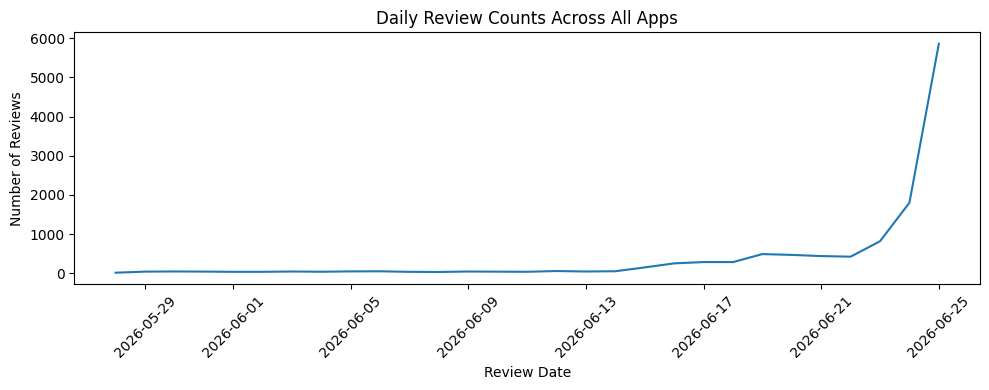

Saved figure: /content/googleplay_10k_eda_outputs/figures/googleplay_10k_eda_20260626_205621_daily_review_counts.png


In [108]:
overall_daily = df.groupby("review_date").size()

plt.figure(figsize=(10, 4))
overall_daily.plot()
plt.title("Daily Review Counts Across All Apps")
plt.xlabel("Review Date")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()

daily_fig_path = FIG_DIR / f"{RUN_ID}_daily_review_counts.png"
plt.savefig(daily_fig_path, dpi=150)
plt.show()

print("Saved figure:", daily_fig_path)

## 17. App Version Coverage

Version fields are useful if later we want to connect reviews with product releases or app updates.  
But I do not want to assume version fields are always complete, so I check coverage by app.

In [109]:
version_summary = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    appVersion_non_missing_pct=("appVersion", lambda s: s.notna().mean() * 100),
    reviewCreatedVersion_non_missing_pct=("reviewCreatedVersion", lambda s: s.notna().mean() * 100),
    unique_app_versions=("appVersion", "nunique"),
    unique_review_created_versions=("reviewCreatedVersion", "nunique")
).reset_index()

version_summary

,app_name,n_reviews,appVersion_non_missing_pct,reviewCreatedVersion_non_missing_pct,unique_app_versions,unique_review_created_versions
0,Airbnb,1200,87.583333,87.583333,29,29
1,DoorDash,1200,89.416667,89.416667,68,68
2,Duolingo,1200,89.500000,89.500000,45,45
3,Instagram,1200,62.750000,62.750000,110,110
4,Netflix,1200,69.333333,69.333333,123,123
5,Spotify,1200,84.916667,84.916667,48,48
6,TikTok,1200,62.000000,62.000000,78,78
7,Uber,1200,85.333333,85.333333,44,44
8,Walmart,1200,94.750000,94.750000,53,53
9,YouTube,1200,97.833333,97.833333,152,152


In [110]:
top_versions = (
    df.groupby(["app_name", "appVersion"])
    .size()
    .reset_index(name="count")
    .sort_values(["app_name", "count"], ascending=[True, False])
)

top_versions.head(50)

,app_name,appVersion,count
25,Airbnb,26.24,283
24,Airbnb,26.23,236
27,Airbnb,26.25.1,180
23,Airbnb,26.22.1,134
21,Airbnb,26.21,93
26,Airbnb,26.25,44
28,Airbnb,26.26,33
22,Airbnb,26.22,8
20,Airbnb,26.20,7
16,Airbnb,26.16,6


In [111]:
version_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_version_summary.csv", index=False)
top_versions.to_csv(OUTPUT_DIR / f"{RUN_ID}_top_versions.csv", index=False)

## 18. Other Data Quality Checks

This section checks a few basic quality flags: missing core fields, invalid scores, future timestamps, low-signal reviews, and duplicates.

The timestamp comparison is done in UTC to avoid timezone errors.

In [112]:
df["at_check_utc"] = pd.to_datetime(df["at"], errors="coerce", utc=True)
now_utc = pd.Timestamp.now(tz="UTC")

future_timestamp_mask = df["at_check_utc"].notna() & (df["at_check_utc"] > now_utc)

valid_score_mask = df["score"].between(1, 5)
invalid_score_mask = df["score"].notna() & (~valid_score_mask)

quality_flags = pd.DataFrame([{
    "total_reviews": len(df),

    "missing_content_rows": int((df["content"].str.strip() == "").sum()),
    "missing_content_pct": (df["content"].str.strip() == "").mean() * 100,

    "missing_score_rows": int(df["score"].isna().sum()),
    "missing_score_pct": df["score"].isna().mean() * 100,

    "invalid_score_rows": int(invalid_score_mask.sum()),
    "invalid_score_pct": invalid_score_mask.mean() * 100,

    "missing_review_id_rows": int(df["reviewId"].isna().sum()),
    "missing_review_id_pct": df["reviewId"].isna().mean() * 100,

    "future_timestamp_rows": int(future_timestamp_mask.sum()),
    "future_timestamp_pct": future_timestamp_mask.mean() * 100,

    "low_signal_rows": int(df["low_signal"].sum()),
    "low_signal_pct": df["low_signal"].mean() * 100,

    "exact_duplicate_review_id_rows": int(df["dup_review_id"].sum()),
    "exact_duplicate_review_id_pct": df["dup_review_id"].mean() * 100,

    "exact_duplicate_content_same_app_rows": int(df["dup_content_same_app"].sum()),
    "exact_duplicate_content_same_app_pct": df["dup_content_same_app"].mean() * 100,

    "exact_duplicate_content_global_rows": int(df["dup_content_global"].sum()),
    "exact_duplicate_content_global_pct": df["dup_content_global"].mean() * 100
}])

quality_flags

,total_reviews,missing_content_rows,missing_content_pct,missing_score_rows,missing_score_pct,invalid_score_rows,invalid_score_pct,missing_review_id_rows,missing_review_id_pct,future_timestamp_rows,future_timestamp_pct,low_signal_rows,low_signal_pct,exact_duplicate_review_id_rows,exact_duplicate_review_id_pct,exact_duplicate_content_same_app_rows,exact_duplicate_content_same_app_pct,exact_duplicate_content_global_rows,exact_duplicate_content_global_pct
0,12000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,4741,39.508333,0,0.0,1941,16.175,2464,20.533333


In [113]:
quality_flags.to_csv(OUTPUT_DIR / f"{RUN_ID}_quality_flags.csv", index=False)

## 19. Optional Score-Text Mismatch Check

This is only a light extra check.  
I use TextBlob to flag cases where the rating and the text may point in different directions.

I would not treat this as a formal sentiment model. It is just one more possible quality signal.

In [114]:
def get_sentiment_polarity(row):
    text = str(row["content"])

    if row["detected_language"] != "en":
        return np.nan

    if row["word_count"] < 3:
        return np.nan

    try:
        return TextBlob(text).sentiment.polarity
    except Exception:
        return np.nan

df["sentiment_polarity"] = df.apply(get_sentiment_polarity, axis=1)

df["score_text_mismatch"] = (
    ((df["score"] <= 2) & (df["sentiment_polarity"] >= 0.35)) |
    ((df["score"] >= 4) & (df["sentiment_polarity"] <= -0.35))
)

mismatch_summary = df.groupby("app_name").agg(
    n_reviews=("reviewId", "size"),
    sentiment_available_pct=("sentiment_polarity", lambda s: s.notna().mean() * 100),
    mismatch_count=("score_text_mismatch", "sum"),
    mismatch_pct=("score_text_mismatch", lambda s: s.mean() * 100)
).reset_index()

mismatch_summary

,app_name,n_reviews,sentiment_available_pct,mismatch_count,mismatch_pct
0,Airbnb,1200,64.000000,14,1.166667
1,DoorDash,1200,79.333333,41,3.416667
2,Duolingo,1200,58.083333,15,1.250000
3,Instagram,1200,42.916667,13,1.083333
4,Netflix,1200,64.250000,32,2.666667
5,Spotify,1200,60.833333,26,2.166667
6,TikTok,1200,39.916667,25,2.083333
7,Uber,1200,48.916667,11,0.916667
8,Walmart,1200,76.333333,12,1.000000
9,YouTube,1200,32.750000,20,1.666667


In [115]:
mismatch_examples = df[df["score_text_mismatch"]][
    ["app_name", "score", "sentiment_polarity", "content", "at"]
].head(50)

mismatch_examples

,app_name,score,sentiment_polarity,content,at
28,YouTube,1,0.350000,it's full of AI brainrot slop. f tier,2026-06-25 20:15:18
74,YouTube,1,0.350000,"Change your damn ai moderation to real humans,...",2026-06-25 19:12:50
101,YouTube,1,0.500000,my internet is ok but reels no play and videos,2026-06-25 18:41:35
143,YouTube,2,0.600000,I can say you you tube helps me watch my favou...,2026-06-25 18:13:13
177,YouTube,5,-0.366667,now is everyday dat I will be updating my YouT...,2026-06-25 17:55:36
182,YouTube,2,0.750000,YouTube is best source of entertainment but I ...,2026-06-25 17:52:43
269,YouTube,1,0.500000,this is take so many update,2026-06-25 17:08:36
331,YouTube,1,0.378788,ads always and love streaming on youtube (watc...,2026-06-25 16:37:35
378,YouTube,4,-1.000000,the made a worst update in which like icon change,2026-06-25 16:15:39
396,YouTube,1,0.910000,very good experience and skills and build the ...,2026-06-25 16:06:58


In [116]:
mismatch_summary.to_csv(OUTPUT_DIR / f"{RUN_ID}_sentiment_mismatch_summary.csv", index=False)
mismatch_examples.to_csv(OUTPUT_DIR / f"{RUN_ID}_sentiment_mismatch_examples.csv", index=False)

## 20. Save Clean Review-Level Data

I save two versions.

The internal file keeps the full review-level data.  
The shareable file removes direct user fields and hashes the review ID, so it is safer to share or upload if needed.

In [117]:
clean_internal_path = OUTPUT_DIR / f"{RUN_ID}_clean_reviews_with_features_internal.csv"
df.to_csv(clean_internal_path, index=False)

public_df = df.copy()

# Hash reviewId for shareable version
public_df["review_id_hash"] = public_df["reviewId"].apply(
    lambda x: hashlib.sha256(str(x).encode("utf-8")).hexdigest()
)

# Remove direct user-level fields for safer sharing
public_df = public_df.drop(columns=[
    "reviewId",
    "userName",
    "userImage"
], errors="ignore")

clean_shareable_path = OUTPUT_DIR / f"{RUN_ID}_clean_reviews_with_features_shareable.csv"
public_df.to_csv(clean_shareable_path, index=False)

print("Saved internal clean file:", clean_internal_path)
print("Saved shareable clean file:", clean_shareable_path)
print("Final rows:", len(df))
print("Final columns internal:", df.shape[1])
print("Final columns shareable:", public_df.shape[1])

Saved internal clean file: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_clean_reviews_with_features_internal.csv
Saved shareable clean file: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_clean_reviews_with_features_shareable.csv
Final rows: 12000
Final columns internal: 30
Final columns shareable: 28


## 21. Final Report Tables

These are the main tables I would use to explain the result.

In [118]:
final_report = {
    "overall_summary": overall_summary,
    "collection_log": collection_log_df,
    "app_summary": app_summary,
    "overall_rating_summary": overall_rating_summary,
    "rating_counts": rating_counts,
    "rating_pct": rating_pct.round(2),
    "length_summary": length_summary,
    "missing_overall": missing_overall,
    "duplicate_summary": duplicate_summary,
    "duplicate_by_app": duplicate_by_app,
    "near_duplicate_summary": near_dup_summary,
    "low_signal_summary": low_signal_summary,
    "language_overall": language_overall,
    "timestamp_summary": timestamp_summary,
    "version_summary": version_summary,
    "quality_flags": quality_flags,
    "sentiment_mismatch_summary": mismatch_summary
}

for name, table in final_report.items():
    print("\n" + "="*90)
    print(name)
    print("="*90)
    display(table)


overall_summary


,total_reviews,unique_apps,unique_review_ids,earliest_review_time,latest_review_time,avg_rating,median_rating,avg_char_len,median_char_len,avg_word_count,median_word_count
0,12000,10,12000,2026-05-28 17:50:21,2026-06-25 20:57:50,3.744417,5.0,74.871833,28.0,14.25575,5.0



collection_log


,app_name,app_id,rows_collected,target_count,collection_status
0,YouTube,com.google.android.youtube,1200,1200,complete
1,TikTok,com.zhiliaoapp.musically,1200,1200,complete
2,Instagram,com.instagram.android,1200,1200,complete
3,Spotify,com.spotify.music,1200,1200,complete
4,Uber,com.ubercab,1200,1200,complete
5,DoorDash,com.dd.doordash,1200,1200,complete
6,Duolingo,com.duolingo,1200,1200,complete
7,Netflix,com.netflix.mediaclient,1200,1200,complete
8,Airbnb,com.airbnb.android,1200,1200,complete
9,Walmart,com.walmart.android,1200,1200,complete



app_summary


...

,app_name,n_reviews,appVersion_non_missing_pct,reviewCreatedVersion_non_missing_pct,unique_app_versions,unique_review_created_versions
0,Airbnb,1200,87.583333,87.583333,29,29
1,DoorDash,1200,89.416667,89.416667,68,68
2,Duolingo,1200,89.500000,89.500000,45,45
3,Instagram,1200,62.750000,62.750000,110,110
4,Netflix,1200,69.333333,69.333333,123,123
5,Spotify,1200,84.916667,84.916667,48,48
6,TikTok,1200,62.000000,62.000000,78,78
7,Uber,1200,85.333333,85.333333,44,44
8,Walmart,1200,94.750000,94.750000,53,53
9,YouTube,1200,97.833333,97.833333,152,152



quality_flags


,total_reviews,missing_content_rows,missing_content_pct,missing_score_rows,missing_score_pct,invalid_score_rows,invalid_score_pct,missing_review_id_rows,missing_review_id_pct,future_timestamp_rows,future_timestamp_pct,low_signal_rows,low_signal_pct,exact_duplicate_review_id_rows,exact_duplicate_review_id_pct,exact_duplicate_content_same_app_rows,exact_duplicate_content_same_app_pct,exact_duplicate_content_global_rows,exact_duplicate_content_global_pct
0,12000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,4741,39.508333,0,0.0,1941,16.175,2464,20.533333



sentiment_mismatch_summary


,app_name,n_reviews,sentiment_available_pct,mismatch_count,mismatch_pct
0,Airbnb,1200,64.000000,14,1.166667
1,DoorDash,1200,79.333333,41,3.416667
2,Duolingo,1200,58.083333,15,1.250000
3,Instagram,1200,42.916667,13,1.083333
4,Netflix,1200,64.250000,32,2.666667
5,Spotify,1200,60.833333,26,2.166667
6,TikTok,1200,39.916667,25,2.083333
7,Uber,1200,48.916667,11,0.916667
8,Walmart,1200,76.333333,12,1.000000
9,YouTube,1200,32.750000,20,1.666667


## 22. Save All Main Summary Files

This saves one Excel file with all main summary tables.  
It also creates a zip file with the main outputs, so the run is easier to share or compare later.

In [119]:
summary_excel_path = OUTPUT_DIR / f"{RUN_ID}_main_summary_tables.xlsx"

with pd.ExcelWriter(summary_excel_path, engine="openpyxl") as writer:
    for name, table in final_report.items():
        sheet_name = name[:31]
        table.to_excel(writer, sheet_name=sheet_name, index=True)

print("Saved summary Excel:", summary_excel_path)

Saved summary Excel: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_main_summary_tables.xlsx


In [120]:
run_manifest = {
    "run_id": RUN_ID,
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "source": "Google Play",
    "lang": LANG,
    "country": COUNTRY,
    "target_per_app": TARGET_PER_APP,
    "page_size": PAGE_SIZE,
    "total_reviews": int(len(df)),
    "unique_apps": int(df["app_name"].nunique()),
    "unique_review_ids": int(df["reviewId"].nunique()),
    "earliest_review_time": str(df["at"].min()),
    "latest_review_time": str(df["at"].max()),
    "avg_rating": float(df["score"].mean()),
    "median_rating": float(df["score"].median()),
    "low_signal_rows": int(df["low_signal"].sum()),
    "low_signal_pct": float(df["low_signal"].mean() * 100),
    "duplicate_review_id_rows": int(df["dup_review_id"].sum()),
    "duplicate_content_same_app_rows": int(df["dup_content_same_app"].sum()),
    "duplicate_content_global_rows": int(df["dup_content_global"].sum()),
    "near_duplicate_pairs": int(len(near_dup_pairs)),
    "english_reviews": int((df["detected_language"] == "en").sum()),
    "too_short_language_reviews": int((df["detected_language"] == "too_short").sum()),
    "app_version_missing_pct": float(df["appVersion"].isna().mean() * 100)
}

manifest_path = OUTPUT_DIR / f"{RUN_ID}_run_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(run_manifest, f, indent=2, default=str)

print("Saved manifest:", manifest_path)

Saved manifest: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_run_manifest.json


In [121]:
# Create a shareable zip.
# I do not include the full internal raw file in this zip.

shareable_files = [
    metadata_path,
    collection_log_path,
    summary_excel_path,
    manifest_path,
    clean_shareable_path
]

# Add all summary CSV files
summary_csv_files = sorted([
    p for p in OUTPUT_DIR.glob(f"{RUN_ID}_*.csv")
    if "raw_reviews_internal" not in p.name
    and "clean_reviews_with_features_internal" not in p.name
])

shareable_files.extend(summary_csv_files)

# Add figures
shareable_files.extend(sorted(FIG_DIR.glob(f"{RUN_ID}_*.png")))

shareable_zip_path = OUTPUT_DIR / f"{RUN_ID}_shareable_outputs.zip"

with zipfile.ZipFile(shareable_zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in shareable_files:
        if Path(file).exists():
            zipf.write(file, arcname=Path(file).name)

print("Created shareable zip:", shareable_zip_path)
print("Files included:", len(shareable_files))

/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'googleplay_10k_eda_20260626_205621_app_metadata.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'googleplay_10k_eda_20260626_205621_clean_reviews_with_features_shareable.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'googleplay_10k_eda_20260626_205621_collection_log.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


Created shareable zip: /content/googleplay_10k_eda_outputs/googleplay_10k_eda_20260626_205621_shareable_outputs.zip
Files included: 38


In [122]:
from google.colab import files

files.download(str(shareable_zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 23. Result Notes from This Run

These notes are based on the actual output from this run.

- Final sample: 12,000 reviews across 10 apps.
- Each app returned 1,200 reviews.
- All 12,000 review IDs are unique.
- Core fields are complete: review ID, content, score, timestamp, thumbs-up count, app name, and app ID.
- Average rating is 3.75 and median rating is 5.0.
- Five-star reviews are the largest group, but one-star reviews are also meaningful.
- No duplicate review IDs were found.
- Repeated text is common, mostly because many users write short generic reviews.
- Low-signal reviews are common and should be flagged for later modeling.
- Timestamps are complete and useful for recurring ingestion.
- App version fields are useful but incomplete, so version-based analysis should be optional.

## 24. Synthesized Summary and Conclusion

This run moves from source validation into a deeper EDA and data quality check. The goal was to understand not only whether Google Play reviews can be collected, but also whether the review data is clean and useful enough for later analysis, modeling, and SQL/database design.

In this run, I collected 12,000 Google Play review records across 10 mainstream apps, with 1,200 reviews per app. The dataset covers reviews from 2026-05-28 17:50:21 to 2026-06-25 20:57:50. All 12,000 review IDs are unique, and the core fields are complete. There are no missing values in review ID, content, score, timestamp, or thumbs-up count.

The rating distribution shows real app-level differences. The overall average rating is 3.74 and the median rating is 5.0. Five-star reviews are the largest group, with 7,177 reviews, or 59.81% of the dataset. One-star reviews are also a meaningful group, with 2,859 reviews, or 23.82%. Duolingo has the highest average rating in this sample at 4.46, while DoorDash has the lowest average rating at 3.05. DoorDash also has the highest one-star share at 38.5%. This means the dataset can support app-level comparison instead of only broad review aggregation.

Review length also varies a lot across apps. DoorDash has the longest average review length at about 111 characters, while YouTube has the shortest average review length at about 43 characters. This means the dataset includes both detailed feedback and very short comments. For text modeling, the short comments need to be flagged or filtered.

The missing field check shows that the core analytical fields are strong. The main missing fields are developer reply content and reply timestamp, both missing in 81.51% of reviews. I do not treat that as a direct data quality problem because many reviews simply do not receive developer replies. App version fields are more important for later analysis. `appVersion` and `reviewCreatedVersion` are each missing in 17.66% of records, so version-level analysis is possible but not fully complete.

The duplicate checks are also useful. There are no duplicate review IDs, which supports the stability of the review identifier. However, repeated review text is common. There are 1,941 rows with exact duplicate content within the same app and 2,464 rows with exact duplicate content globally. These repeated texts are mostly generic short comments such as “amazing,” “awesome,” or “best app,” so I would treat this as a content quality issue, not a collection error.

For near-duplicate text, I used a simple TF-IDF and cosine similarity check with a 0.92 threshold. This found 16 near-duplicate pairs. The number is small compared with the full dataset, but I would still keep near-duplicate tracking as a future quality check.

The low-signal review check is one of the most important findings. In total, 4,741 reviews, or about 39.51% of the dataset, were flagged as low-signal. YouTube, TikTok, Instagram, and Uber had the highest low-signal shares. This does not make the data unusable, but it means later text analysis should keep the `low_signal` and `low_signal_reason` fields.

The language check shows that US / English collection settings do not guarantee fully English review text. About 57.48% of reviews were detected as English, and 33.68% were too short for reliable language detection. The rest were detected as other languages or unknown. For later NLP work, I would keep the detected language field and decide whether to focus only on English reviews.

The timestamp fields are complete and usable. Some high-volume apps returned 1,200 recent reviews within the same day, while Airbnb covered 28 days. This supports recurring ingestion because future runs can compare records by review ID and timestamp.

Overall, this deeper EDA supports the earlier conclusion that Google Play is the stronger primary source for the first recurring review ingestion pilot. The data is structurally clean enough for downstream analysis and later database design. The main quality issues are manageable: low-signal content, repeated generic text, incomplete app version coverage, and mixed or too-short language signals. The next step should be to design the SQL/database schema around these observed fields and include quality flags for missing version fields, low-signal reviews, duplicate content, detected language, timestamps, and optional developer reply fields.